In [3]:
import pandas as pd

# Dataset load
df = pd.read_csv(r"C:\Users\dorap\Downloads\inv\house-prices-advanced-regression-techniques\train.csv")

# Features and Target
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
X_train.shape

(1168, 245)

In [10]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [11]:
X_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,255,20,70.0,8400,5,6,1957,1957,0.0,922,...,False,False,False,False,True,False,False,False,True,False
1066,1067,60,59.0,7837,6,7,1993,1994,0.0,0,...,False,False,False,False,True,False,False,False,True,False
638,639,30,67.0,8777,5,7,1910,1950,0.0,0,...,False,False,False,False,True,False,False,False,True,False
799,800,50,60.0,7200,5,7,1937,1950,252.0,569,...,False,False,False,False,True,False,False,False,True,False
380,381,50,50.0,5000,5,6,1924,1950,0.0,218,...,False,False,False,False,True,False,False,False,True,False


In [12]:
print(X_train.dtypes[X_train.dtypes == 'object'])

Series([], dtype: object)


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(r"C:\Users\dorap\Downloads\inv\house-prices-advanced-regression-techniques\train.csv")

y = df["SalePrice"]
X = df.drop("SalePrice", axis=1)

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Fill missing values
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [7]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(scores)

print("Average R2:")
print(scores.mean())

Cross Validation Scores:
[0.86010725 0.28138735 0.717763   0.71356715 0.65270718]
Average R2:
0.6451063851953599


In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {
    'alpha':[0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train,y_train)

print("Best Alpha:")
print(ridge_grid.best_params_)

print("Best Score:")
print(ridge_grid.best_score_)

Best Alpha:
{'alpha': 10}
Best Score:
0.810501698224054


In [11]:
residuals = y_test - y_pred

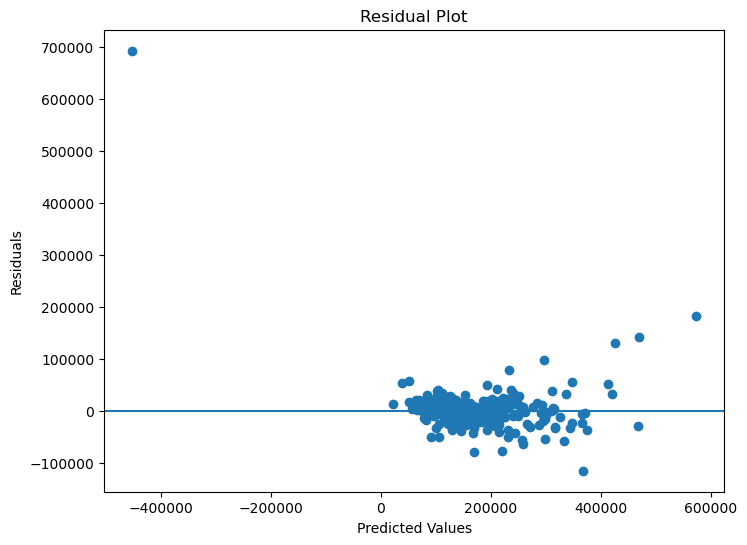

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

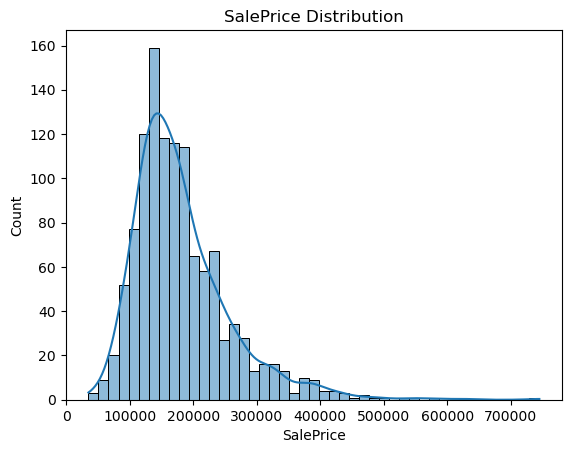

In [13]:
import seaborn as sns

sns.histplot(y_train,kde=True)

plt.title("SalePrice Distribution")

plt.show()

In [14]:
import numpy as np

y_log = np.log1p(y)

In [15]:
mean_price = y_train.mean()

baseline_pred = [mean_price] * len(y_test)

In [16]:
from sklearn.metrics import r2_score

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print(baseline_r2)

-0.0008824918802490256


In [17]:
import pandas as pd

error_df = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})

error_df['Error'] = abs(
    error_df['Actual']
    -
    error_df['Predicted']
)

error_df.sort_values(
    by='Error',
    ascending=False
).head(10)

,Actual,Predicted,Error
271,241500,-451830.257635,693330.257635
691,755000,572998.015340,182001.984660
898,611657,468522.055887,143134.944113
1046,556581,425034.341548,131546.658452
581,253293,368381.051349,115088.051349
774,395000,297268.500654,97731.499346
479,89471,169229.471324,79758.471324
218,311500,233151.481412,78348.518588
588,143000,220645.163627,77645.163627
1138,196000,258808.635305,62808.635305


In [18]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

In [19]:
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train_poly
)

poly_pred = poly_model.predict(
    X_test_poly
)

In [20]:
from sklearn.metrics import r2_score

poly_r2 = r2_score(
    y_test_poly,
    poly_pred
)

print(poly_r2)

-0.25332374070905295


In [21]:
results = pd.DataFrame({
    'Model':[
        'Baseline',
        'Linear Regression',
        'Polynomial'
    ],
    'R2 Score':[
        baseline_r2,
        r2_score(y_test,y_pred),
        poly_r2
    ]
})

print(results)

               Model  R2 Score
0           Baseline -0.000882
1  Linear Regression  0.683270
2         Polynomial -0.253324


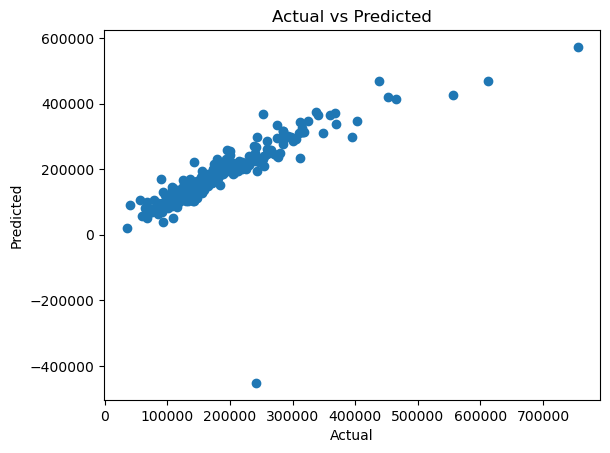

In [22]:
plt.scatter(y_test,y_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

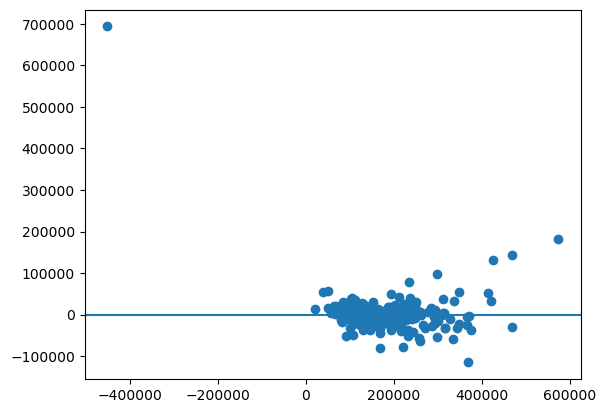

In [23]:
plt.scatter(y_pred,residuals)

plt.axhline(y=0)

plt.show()